In [9]:
import math
from dataclasses import dataclass
from typing import Optional, Dict, Any
import sys, os
sys.path.append(os.path.abspath('../src/'))
from dataset import TrainDataset
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from dotenv import load_dotenv
import numpy as np
load_dotenv()



True

In [10]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

# ---- 2D sinusoidal position embedding (32x32) ----
def build_2d_sincos_pos_embed(h, w, dim, device=None):
    assert dim % 4 == 0, "dim must be divisible by 4 for 2D sin/cos"
    y = torch.arange(h, device=device).float()
    x = torch.arange(w, device=device).float()
    yy, xx = torch.meshgrid(y, x, indexing="ij")  # (H,W)

    omega = torch.arange(dim // 4, device=device).float()
    omega = 1.0 / (10000 ** (omega / (dim // 4)))

    out_y = yy[..., None] * omega[None, None, :]  # (H,W,D/4)
    out_x = xx[..., None] * omega[None, None, :]

    pos = torch.cat([torch.sin(out_y), torch.cos(out_y),
                     torch.sin(out_x), torch.cos(out_x)], dim=-1)  # (H,W,D)
    return pos  # (H,W,dim)

# ---- Slot Attention (Locatello et al.) ----
class SlotAttention(nn.Module):
    def __init__(self, num_slots: int, in_dim: int, slot_dim: int,
                 iters: int = 3, eps: float = 1e-8, hidden_dim: int = 128):
        super().__init__()
        self.num_slots = num_slots
        self.iters = iters
        self.eps = eps
        self.scale = slot_dim ** -0.5

        self.norm_inputs = nn.LayerNorm(in_dim)
        self.norm_slots  = nn.LayerNorm(slot_dim)
        self.norm_mlp    = nn.LayerNorm(slot_dim)

        # slots init
        self.slots_mu = nn.Parameter(torch.zeros(1, 1, slot_dim))
        self.slots_sigma = nn.Parameter(torch.ones(1, 1, slot_dim))

        # attention projections
        self.to_q = nn.Linear(slot_dim, slot_dim, bias=False)
        self.to_k = nn.Linear(in_dim,   slot_dim, bias=False)
        self.to_v = nn.Linear(in_dim,   slot_dim, bias=False)

        # slot update
        self.gru = nn.GRUCell(slot_dim, slot_dim)
        self.mlp = nn.Sequential(
            nn.Linear(slot_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, slot_dim),
        )

    def forward(self, inputs):
        """
        inputs: (B, N, in_dim)  # N = トークン数(= T*32*32)
        returns:
          slots: (B, K, slot_dim)
          attn : (B, K, N)  # 各トークン→スロットのsoft assignment
        """
        B, N, D = inputs.shape
        inputs = self.norm_inputs(inputs)

        # init slots (B,K,slot_dim)
        mu = self.slots_mu.expand(B, self.num_slots, -1)
        sigma = self.slots_sigma.expand(B, self.num_slots, -1)
        slots = mu + sigma * torch.randn_like(mu)

        k = self.to_k(inputs)   # (B,N,slot_dim)
        v = self.to_v(inputs)   # (B,N,slot_dim)

        for _ in range(self.iters):
            slots_prev = slots
            slots_norm = self.norm_slots(slots)
            q = self.to_q(slots_norm)  # (B,K,slot_dim)

            # attn logits: (B,K,N)
            attn_logits = torch.einsum("bkd,bnd->bkn", q, k) * self.scale
            attn = F.softmax(attn_logits, dim=1)  # softmax over slots (K)
            attn = attn + self.eps
            attn = attn / attn.sum(dim=-1, keepdim=True)  # normalize over N (optional安定化)

            # weighted sum: (B,K,slot_dim)
            updates = torch.einsum("bkn,bnd->bkd", attn, v)

            # GRU update (flatten K)
            slots = self.gru(
                updates.reshape(B * self.num_slots, -1),
                slots_prev.reshape(B * self.num_slots, -1)
            )
            slots = slots.reshape(B, self.num_slots, -1)
            slots = slots + self.mlp(self.norm_mlp(slots))

        return slots, attn

# ---- Token -> embedding encoder (discrete token ids) ----
class TokenSlotEncoder(nn.Module):
    def __init__(self, vocab_size: int, emb_dim: int, num_slots: int,
                 slot_dim: int, iters: int = 3, T: int = 3, H: int = 32, W: int = 32):
        super().__init__()
        self.T, self.H, self.W = T, H, W
        self.emb = nn.Embedding(vocab_size, emb_dim)

        # pos emb (固定) : (H,W,emb_dim)
        self.register_buffer("pos2d", build_2d_sincos_pos_embed(H, W, emb_dim), persistent=False)

        # time embedding（3フレーム分）
        self.time_emb = nn.Embedding(T, emb_dim)

        # small MLP before slot-attn
        self.pre = nn.Sequential(
            nn.LayerNorm(emb_dim),
            nn.Linear(emb_dim, emb_dim),
            nn.ReLU(inplace=True),
            nn.Linear(emb_dim, emb_dim),
        )

        self.slot_attn = SlotAttention(num_slots=num_slots, in_dim=emb_dim, slot_dim=slot_dim, iters=iters)

    def forward(self, token_frames: torch.Tensor):
        """
        token_frames: (B, T, H, W)  int64 token ids
        returns:
          slots: (B, K, slot_dim)
          attn : (B, K, T, H, W)  # 各トークン→スロット assignment を空間/時間形状で返す
        """
        B, T, H, W = token_frames.shape
        assert (T, H, W) == (self.T, self.H, self.W)

        x = self.emb(token_frames)  # (B,T,H,W,emb_dim)
        x = x + self.pos2d[None, None, :, :, :]  # add 2D pos
        t_ids = torch.arange(T, device=token_frames.device)
        x = x + self.time_emb(t_ids)[None, :, None, None, :]  # add time emb

        x = self.pre(x)  # (B,T,H,W,emb_dim)
        x = x.reshape(B, T*H*W, -1)  # (B,N,D) N=3072

        slots, attn = self.slot_attn(x)          # attn: (B,K,N)
        attn = attn.reshape(B, -1, T, H, W)      # (B,K,T,H,W)
        return slots, attn


In [11]:
from torch.utils.data import DataLoader

# ds はあなたが作った ShardedSlidingBlockDataset（robot_states付き版でもOK）
# 例:
ds = TrainDataset(
    root="/root/work/data/raw/train_v2.0",
    output_format="seq2seq",
    cache_path="/root/work/data/outputs/valid_starts_stride3_clipclean.npy",
)

loader = DataLoader(ds, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)

device = "cuda"
vocab_size = 65536   # ← トークン最大値に合わせて調整（min/max見て決める）
emb_dim = 256
slot_dim = 256
num_slots = 8
iters = 3

model = TokenSlotEncoder(
    vocab_size=vocab_size,
    emb_dim=emb_dim,
    num_slots=num_slots,
    slot_dim=slot_dim,
    iters=iters,
    T=3, H=32, W=32,
).to(device)

batch = next(iter(loader))

# past_frames: numpy (B?,3,32,32) で入ってくる想定（あなたのDatasetがそう返している）
past_any = batch["past_frames"]

if isinstance(past_any, torch.Tensor):
    past = past_any.long()
elif isinstance(past_any, np.ndarray):
    past = torch.from_numpy(past_any).long()
elif isinstance(past_any, list):
    # list of numpy or list of tensor の両方を吸収
    if isinstance(past_any[0], torch.Tensor):
        past = torch.stack([x.long() for x in past_any], dim=0)
    else:
        past = torch.from_numpy(np.stack(past_any, axis=0)).long()
else:
    raise TypeError(f"Unsupported type for past_frames: {type(past_any)}")

past = past.to(device)  # (B,3,32,32)
slots, attn = model(past)
print("slots:", slots.shape, "attn:", attn.shape)


slots: torch.Size([8, 8, 256]) attn: torch.Size([8, 8, 3, 32, 32])


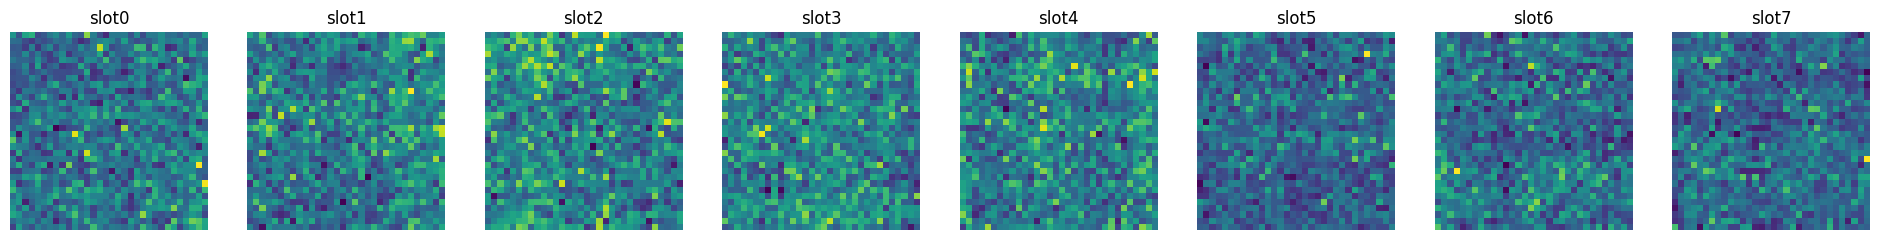

In [6]:
import matplotlib.pyplot as plt

b = 0
t = 0
K = attn.shape[1]

fig, axes = plt.subplots(1, K, figsize=(3*K, 3))
for k in range(K):
    axes[k].imshow(attn[b, k, t].detach().cpu().numpy())
    axes[k].set_title(f"slot{k}")
    axes[k].axis("off")
plt.show()


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# --------- Slot Attention (前に渡したものと同じ) ---------
class SlotAttention(nn.Module):
    def __init__(self, num_slots: int, in_dim: int, slot_dim: int,
                 iters: int = 3, eps: float = 1e-8, hidden_dim: int = 128):
        super().__init__()
        self.num_slots = num_slots
        self.iters = iters
        self.eps = eps
        self.scale = slot_dim ** -0.5

        self.norm_inputs = nn.LayerNorm(in_dim)
        self.norm_slots  = nn.LayerNorm(slot_dim)
        self.norm_mlp    = nn.LayerNorm(slot_dim)

        self.slots_mu = nn.Parameter(torch.zeros(1, 1, slot_dim))
        self.slots_sigma = nn.Parameter(torch.ones(1, 1, slot_dim))

        self.to_q = nn.Linear(slot_dim, slot_dim, bias=False)
        self.to_k = nn.Linear(in_dim,   slot_dim, bias=False)
        self.to_v = nn.Linear(in_dim,   slot_dim, bias=False)

        self.gru = nn.GRUCell(slot_dim, slot_dim)
        self.mlp = nn.Sequential(
            nn.Linear(slot_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, slot_dim),
        )

    def forward(self, inputs):
        # inputs: (B,N,in_dim)
        B, N, D = inputs.shape
        inputs = self.norm_inputs(inputs)

        mu = self.slots_mu.expand(B, self.num_slots, -1)
        sigma = self.slots_sigma.expand(B, self.num_slots, -1)
        slots = mu + sigma * torch.randn_like(mu)

        k = self.to_k(inputs)  # (B,N,slot_dim)
        v = self.to_v(inputs)  # (B,N,slot_dim)

        for _ in range(self.iters):
            slots_prev = slots
            q = self.to_q(self.norm_slots(slots))   # (B,K,slot_dim)

            attn_logits = torch.einsum("bkd,bnd->bkn", q, k) * self.scale
            attn = F.softmax(attn_logits, dim=1)  # over slots
            attn = attn + self.eps
            attn = attn / attn.sum(dim=-1, keepdim=True)

            updates = torch.einsum("bkn,bnd->bkd", attn, v)
            slots = self.gru(
                updates.reshape(B*self.num_slots, -1),
                slots_prev.reshape(B*self.num_slots, -1)
            ).reshape(B, self.num_slots, -1)
            slots = slots + self.mlp(self.norm_mlp(slots))

        return slots, attn  # attn: (B,K,N)

# --------- Pos / Time Emb ---------
def build_2d_sincos_pos_embed(h, w, dim, device=None):
    assert dim % 4 == 0
    y = torch.arange(h, device=device).float()
    x = torch.arange(w, device=device).float()
    yy, xx = torch.meshgrid(y, x, indexing="ij")

    omega = torch.arange(dim // 4, device=device).float()
    omega = 1.0 / (10000 ** (omega / (dim // 4)))

    out_y = yy[..., None] * omega[None, None, :]
    out_x = xx[..., None] * omega[None, None, :]
    pos = torch.cat([torch.sin(out_y), torch.cos(out_y),
                     torch.sin(out_x), torch.cos(out_x)], dim=-1)
    return pos  # (H,W,dim)

# --------- Slot AE on Token-Embeddings (MSE reconstruction) ---------
class TokenSlotAE(nn.Module):
    """
    tokens -> embedding(+pos+time) -> SlotAttention -> decode per-slot embeddings -> mix with attn -> MSE
    """
    def __init__(
        self,
        vocab_size: int,
        emb_dim: int = 256,
        num_slots: int = 8,
        slot_dim: int = 256,
        iters: int = 3,
        T: int = 3, H: int = 32, W: int = 32,
        dec_hidden: int = 512,
    ):
        super().__init__()
        self.T, self.H, self.W = T, H, W
        self.N = T * H * W

        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.time_emb = nn.Embedding(T, emb_dim)
        self.register_buffer("pos2d", build_2d_sincos_pos_embed(H, W, emb_dim), persistent=False)

        self.pre = nn.Sequential(
            nn.LayerNorm(emb_dim),
            nn.Linear(emb_dim, emb_dim),
            nn.ReLU(inplace=True),
            nn.Linear(emb_dim, emb_dim),
        )

        self.slot_attn = SlotAttention(num_slots=num_slots, in_dim=emb_dim, slot_dim=slot_dim, iters=iters)

        # decode: slot -> per-position embedding
        # 位置情報を decoder に入れて「slot×pos -> emb」を作る
        self.dec_pos = nn.Linear(emb_dim, slot_dim, bias=False)  # pos emb を slot空間へ
        self.dec = nn.Sequential(
            nn.LayerNorm(slot_dim),
            nn.Linear(slot_dim, dec_hidden),
            nn.ReLU(inplace=True),
            nn.Linear(dec_hidden, emb_dim),
        )

    def forward(self, token_frames: torch.Tensor):
        """
        token_frames: (B,T,H,W) int64
        returns:
          pred_emb: (B,N,emb_dim)
          tgt_emb : (B,N,emb_dim)
          attn    : (B,K,N)
        """
        B, T, H, W = token_frames.shape
        assert (T, H, W) == (self.T, self.H, self.W)

        # target embedding
        tgt = self.emb(token_frames)  # (B,T,H,W,E)

        # add pos+time
        x = tgt + self.pos2d[None, None, :, :, :]  # (B,T,H,W,E)
        t_ids = torch.arange(T, device=token_frames.device)
        x = x + self.time_emb(t_ids)[None, :, None, None, :]

        x = self.pre(x).reshape(B, self.N, -1)  # (B,N,E)

        slots, attn = self.slot_attn(x)         # slots:(B,K,S), attn:(B,K,N)

        # decoder: make per-slot per-position embeddings
        pos = (self.pos2d[None, :, :, :].expand(B, H, W, -1)).reshape(B, H*W, -1)  # (B,1024,E)
        # time拡張して (B,N,E)
        pos = pos[:, None, :, :].expand(B, T, H*W, -1).reshape(B, self.N, -1)     # (B,N,E)
        pos_s = self.dec_pos(pos)  # (B,N,S)

        # slot( B,K,S ) と pos_s( B,N,S ) を足して decode
        # slot_pos: (B,K,N,S)
        slot_pos = slots[:, :, None, :] + pos_s[:, None, :, :]
        per_slot_emb = self.dec(slot_pos)  # (B,K,N,E)

        # mix using attn: (B,K,N) -> (B,N,E)
        pred = torch.einsum("bkn,bkne->bne", attn, per_slot_emb)

        tgt_flat = tgt.reshape(B, self.N, -1)
        return pred, tgt_flat, attn

    @torch.no_grad()
    def forward_parts(self, token_frames: torch.Tensor):
        """
        return slots/attn/per_slot_emb/slot_contrib/mixed/tgt_emb
        """
        B, T, H, W = token_frames.shape
        assert (T, H, W) == (self.T, self.H, self.W)

        tgt = self.emb(token_frames)  # (B,T,H,W,E)

        x = tgt + self.pos2d[None, None, :, :, :]
        t_ids = torch.arange(T, device=token_frames.device)
        x = x + self.time_emb(t_ids)[None, :, None, None, :]

        x = self.pre(x).reshape(B, self.N, -1)  # (B,N,E)

        slots, attn = self.slot_attn(x)         # slots:(B,K,S), attn:(B,K,N)

        # pos -> slot space
        pos = (self.pos2d[None, :, :, :].expand(B, H, W, -1)).reshape(B, H*W, -1)  # (B,1024,E)
        pos = pos[:, None, :, :].expand(B, T, H*W, -1).reshape(B, self.N, -1)     # (B,N,E)
        pos_s = self.dec_pos(pos)  # (B,N,S)

        slot_pos = slots[:, :, None, :] + pos_s[:, None, :, :]      # (B,K,N,S)
        per_slot_emb = self.dec(slot_pos)                           # (B,K,N,E)

        slot_contrib = attn[..., None] * per_slot_emb               # (B,K,N,E)
        mixed = slot_contrib.sum(dim=1)                             # (B,N,E)

        tgt_flat = tgt.reshape(B, self.N, -1)                       # (B,N,E)
        return {
            "slots": slots,
            "attn": attn,
            "per_slot_emb": per_slot_emb,
            "slot_contrib_emb": slot_contrib,
            "mixed_emb": mixed,
            "tgt_emb": tgt_flat,
        }


In [15]:
from torch.utils.data import DataLoader
from tqdm import tqdm

def get_past_tensor(batch, device):
    x = batch["past_frames"]
    if isinstance(x, torch.Tensor):
        return x.long().to(device)
    if isinstance(x, np.ndarray):
        return torch.from_numpy(x).long().to(device)
    if isinstance(x, list):
        if isinstance(x[0], torch.Tensor):
            return torch.stack([t.long() for t in x], dim=0).to(device)
        return torch.from_numpy(np.stack(x, axis=0)).long().to(device)
    raise TypeError(type(x))

device = "cuda"
loader = DataLoader(ds, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)

# vocab_size は「とりあえず 65536」にしておく（token maxに合わせて後で調整推奨）
vocab_size = 65536

model = TokenSlotAE(
    vocab_size=vocab_size,
    emb_dim=256,
    num_slots=8,
    slot_dim=256,
    iters=3,
    T=3, H=32, W=32,
).to(device)

opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scaler = torch.cuda.amp.GradScaler()

model.train()
for epoch in range(1):
    pbar = tqdm(loader, desc=f"epoch {epoch}")
    for batch in pbar:
        tok = get_past_tensor(batch, device)  # (B,3,32,32)

        opt.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(dtype=torch.bfloat16):
            pred_emb, tgt_emb, attn = model(tok)
            loss = F.mse_loss(pred_emb, tgt_emb)
            attn_eps = 1e-8
            entropy = -(attn * (attn + attn_eps).log()).sum(dim=1).mean()  # slot方向entropy
            # entropy を小さくしたいなら +lambda*entropy（※符号注意）
            loss = loss + 1e-3 * entropy

            # slot usage: 平均割当が偏り過ぎないように
            usage = attn.mean(dim=-1)  # (B,K)
            uniform = torch.full_like(usage, 1.0 / usage.shape[1])
            loss = loss + 1e-3 * F.kl_div((usage+attn_eps).log(), uniform, reduction="batchmean")

        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt)
        scaler.update()

        pbar.set_postfix(loss=float(loss.detach().cpu()))


/tmp/ipykernel_1589/2277488210.py:32: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
epoch 0:   0%|          | 0/77454 [00:00<?, ?it/s]/tmp/ipykernel_1589/2277488210.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=torch.bfloat16):
epoch 0: 100%|██████████| 77454/77454 [41:39<00:00, 30.98it/s, loss=0.00605]


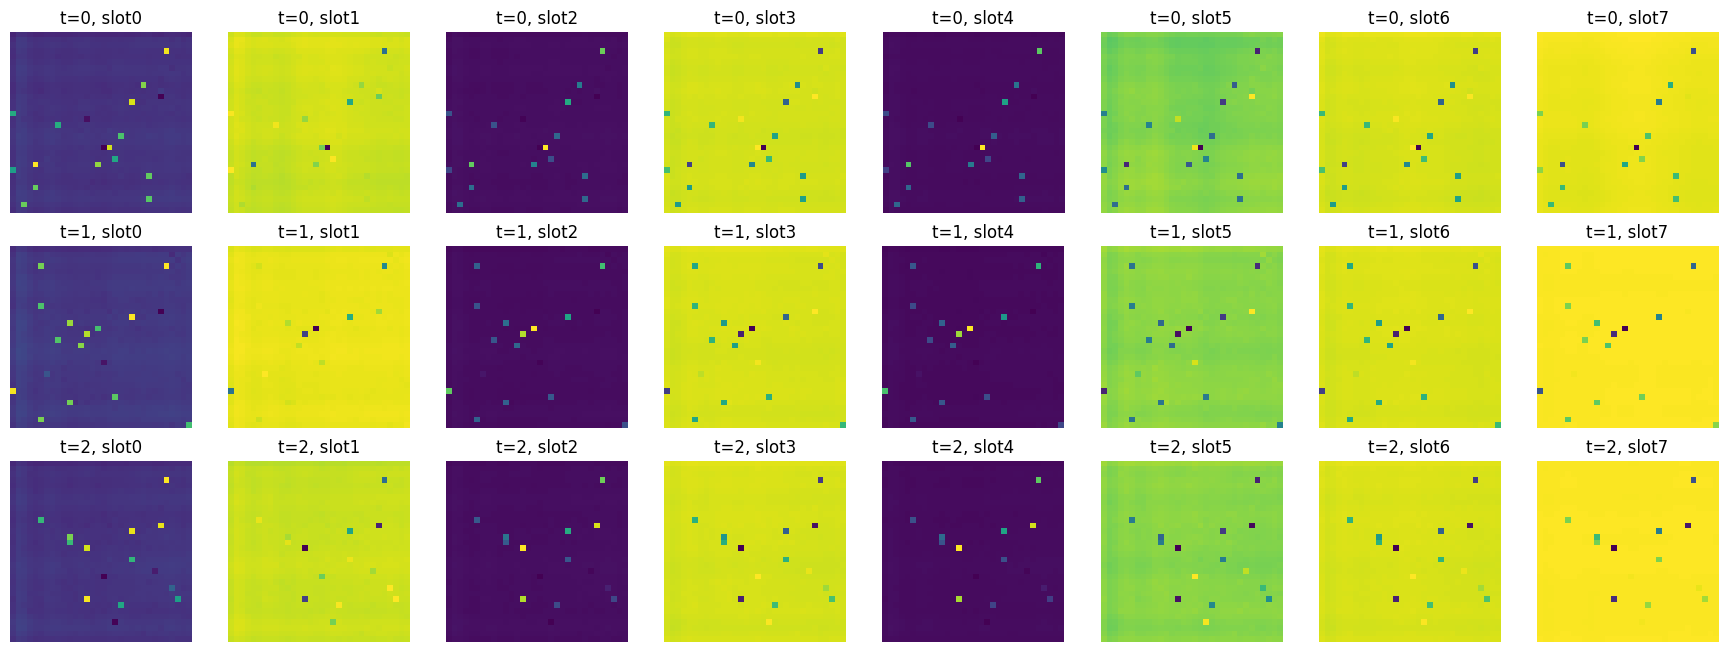

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def visualize_slot_attention(model, batch, device="cuda", b=0, T=3, H=32, W=32, max_slots=8):
    model.eval()

    # past_frames を tensor 化
    x = batch["past_frames"]
    if isinstance(x, torch.Tensor):
        tok = x.long().to(device)
    elif isinstance(x, np.ndarray):
        tok = torch.from_numpy(x).long().to(device)
    elif isinstance(x, list):
        tok = torch.stack([t.long() if isinstance(t, torch.Tensor) else torch.from_numpy(t).long()
                           for t in x], dim=0).to(device)
    else:
        raise TypeError(type(x))

    pred_emb, tgt_emb, attn = model(tok)     # attn: (B,K,N)
    B, K, N = attn.shape
    attn_map = attn.reshape(B, K, T, H, W).detach().cpu()

    Kshow = min(K, max_slots)
    fig, axes = plt.subplots(T, Kshow, figsize=(2.2*Kshow, 2.2*T))
    if T == 1: axes = np.expand_dims(axes, 0)
    if Kshow == 1: axes = np.expand_dims(axes, 1)

    for t in range(T):
        for k in range(Kshow):
            axes[t, k].imshow(attn_map[b, k, t])
            axes[t, k].set_title(f"t={t}, slot{k}")
            axes[t, k].axis("off")
    plt.tight_layout()
    plt.show()

# 使い方:
batch = next(iter(loader))
visualize_slot_attention(model, batch, device="cuda")
